# Hail → Solar · M2 → M3 — severity / damage (how bad is it, if it hits?)

**Asset:** Hayhurst Texas Solar (EIA 66880) · **Peril:** Hail · **Layer:** M3 (severity / damage)

M2 told us *whether* each event hits (the probability `pᵢ`). M3 answers the other half: **given an event
reaches the asset, how much damage does it do?** We map each event's hail size through a **curated** PV
damage curve → a damage ratio → the conditional dollar loss.

**Two rules that define this stage (methodology §6 + §12):**
1. **Curated, not fitted.** We have *event data* (hail sizes), not a history of what hail cost this plant —
   so we *curate* a `size → damage ratio` curve from literature and apply it. Its **provenance**, not a fit
   statistic, is what the number rests on.
2. **Conditional on hit — the full loss.** This is the loss *if it hits*. We do **NOT** multiply by `pᵢ`
   here; `pᵢ` stays in frequency for Phase 5's Bernoulli draw. (Multiplying them = the variance-killing
   Method-0 shortcut the whole rebuild exists to avoid.)

Plan: `docs/plans/hail/done/phase-4-damage.md` · refs: A22 (damage representation), methodology §6/§12.

## Assumptions (this layer)

**A15** damage curve = **capex-weighted subsystem blend** (infrasure-damage-curves: PV_MODULE L=0.95 +
TRACKER L=0.40 × NREL capex weights → asset caps ~34%) · **A16** logistic **saturates** (no extrapolation —
retired) · **A17** scalar mean damage *(no conditional distribution — deferred)* · **A18** duration/BI
**deferred** — physical repair cost only; downtime → revenue is a later stage · **A19** asset value = $36.78M. Full register:
[assumptions A15–A19](../../../../docs/plans/hail/assumptions.md#m3--severity--damage).

In [1]:
from __future__ import annotations
import json
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})

def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / ".env").exists() or (p / "AGENTS.md").exists():
            return p
    raise FileNotFoundError("repo root not found")
ROOT = _repo_root()

ASSET = {"name": "Hayhurst Texas Solar", "eia_plant_id": 66880, "ac_capacity_mw": 24.8,
         "asset_value_usd": 36_778_400}
print(f"asset: {ASSET['name']} | value = ${ASSET['asset_value_usd']:,}")

asset: Hayhurst Texas Solar | value = $36,778,400


## 1 · Load the M2 coupled events

Each event carries its hail size (`peak_intensity_mm/in`) — the input to the damage curve — and its hit
probability `pᵢ`, which we **carry through untouched** (it is *not* used in this stage's math).

In [2]:
ev = gpd.read_parquet(ROOT / "data/hail/hayhurst_hail_m2_coupled.parquet")
print(f"{len(ev)} coupled events | hail size {ev.peak_intensity_mm.min():.0f}–{ev.peak_intensity_mm.max():.0f} mm "
      f"({ev.peak_intensity_in.min():.2f}–{ev.peak_intensity_in.max():.2f} in)")
ev[["event_id", "peak_intensity_mm", "peak_intensity_in", "p_hit"]].sort_values("peak_intensity_mm", ascending=False)

158 coupled events | hail size 26–118 mm (1.00–4.67 in)


,event_id,peak_intensity_mm,peak_intensity_in,p_hit
119,mrms_hail_20250607,118.5,4.67,0.048632
36,mrms_hail_20220601,114.6,4.51,0.072968
17,mrms_hail_20210609,110.7,4.36,0.001020
108,mrms_hail_20250426,99.8,3.93,0.066710
90,mrms_hail_20240601,95.5,3.76,0.050030
...,...,...,...,...
12,mrms_hail_20210530,26.0,1.02,0.000143
129,mrms_hail_20250624,25.9,1.02,0.000143
55,mrms_hail_20221016,25.8,1.02,0.000152
9,mrms_hail_20210527,25.7,1.01,0.000143


## 2 · The damage curve — a **capex-weighted subsystem blend** (infrasure-damage-curves)

**Provenance:** the [`infrasure-damage-curves`](../../../infrasure-damage-curves) library. There's no
pre-built asset curve — we **aggregate** subsystem fragility (logistic `L/(1+exp(-k(x-x0)))`) by NREL capex
weight: **`Asset_DR(x) = Σ wᵢ·DRᵢ(x)`**, subsystems with no hail curve → 0. For Hayhurst (single-axis
tracking): **PV_ARRAY** (w=0.32, module `L=0.95, x0=59.2`; IBHS/IEC empirical) + **MOUNTING** (w=0.10,
tracker `L=0.40`) + ~0 for the hail-immune rest (inverters/substation/electrical/civil/SCADA, ~36% of
value). It **caps at ~34%** and *saturates naturally* — superseding the §12 literature curve (which
extrapolated to ~100%) and the model-gpr `L=0.50` fallback. Spec vendored in `data/hail/damage_curves/`.

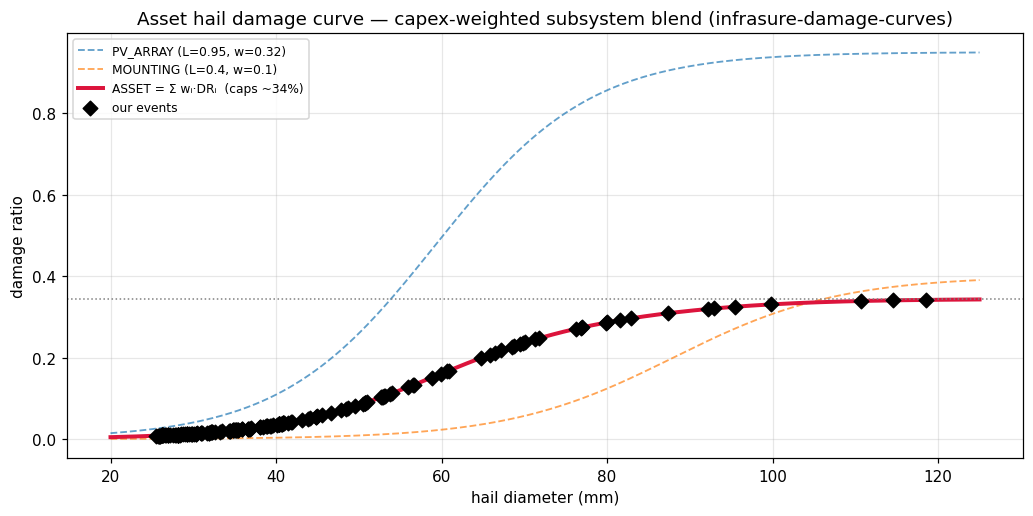

asset curve caps at 34.4%  (PV_ARRAY 0.32×0.95 + MOUNTING 0.10×0.40); ~36% of asset value hail-immune → 0


In [3]:
SPEC = json.load(open(ROOT / "data/hail/damage_curves/hail_solar_asset_capex_weighted.json"))
SUBS = SPEC["subsystems"]

def logistic(x, L, k, x0):
    return L / (1.0 + np.exp(-k * (np.asarray(x, dtype="float64") - x0)))

def damage_ratio(size_mm):                                   # Asset_DR = Σ wᵢ·DRᵢ  (uncovered subsystems → 0)
    return sum(s["capex_weight"] * logistic(size_mm, s["L"], s["k"], s["x0"]) for s in SUBS)

cap = sum(s["capex_weight"] * s["L"] for s in SUBS)          # asset max DR (saturation)
grid = np.linspace(20, 125, 400)
fig, ax = plt.subplots(figsize=(9.5, 4.8))
for s in SUBS:
    ax.plot(grid, logistic(grid, s["L"], s["k"], s["x0"]), lw=1.2, ls="--", alpha=0.7,
            label=f"{s['subsystem']} (L={s['L']}, w={s['capex_weight']})")
ax.plot(grid, damage_ratio(grid), color="crimson", lw=2.6, label=f"ASSET = Σ wᵢ·DRᵢ  (caps ~{cap:.0%})")
ax.scatter(ev.peak_intensity_mm, damage_ratio(ev.peak_intensity_mm), color="black", s=45, marker="D",
           zorder=6, label="our events")
ax.axhline(cap, color="gray", ls=":", lw=1)
ax.set(title="Asset hail damage curve — capex-weighted subsystem blend (infrasure-damage-curves)",
       xlabel="hail diameter (mm)", ylabel="damage ratio"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(f"asset curve caps at {cap:.1%}  (PV_ARRAY 0.32×0.95 + MOUNTING 0.10×0.40); ~36% of asset value hail-immune → 0")

## 3 · Apply the curve → damage ratio + conditional loss per event

`conditional_loss = damage_ratio × asset_value` — the **full** loss *if the event hits*. Note again: **no
`pᵢ` multiplied in.** `pᵢ` is carried alongside for Phase 5, where it drives a Bernoulli hit/miss; on a hit,
*this* full conditional loss applies.

In [4]:
ev["damage_ratio"] = damage_ratio(ev.peak_intensity_mm)
ev["conditional_loss_usd"] = (ev["damage_ratio"] * ASSET["asset_value_usd"]).round(0)
show = ev[["event_id", "peak_intensity_mm", "peak_intensity_in", "damage_ratio", "conditional_loss_usd",
           "p_hit"]].sort_values("conditional_loss_usd", ascending=False)
print(f"conditional losses (full loss IF the event hits) — range "
      f"${ev.conditional_loss_usd.min():,.0f} … ${ev.conditional_loss_usd.max():,.0f}  "
      f"(max {100*ev.conditional_loss_usd.max()/ASSET['asset_value_usd']:.0f}% of TIV — curve caps at {cap:.0%})")
show

conditional losses (full loss IF the event hits) — range $304,379 … $12,564,949  (max 34% of TIV — curve caps at 34%)


,event_id,peak_intensity_mm,peak_intensity_in,damage_ratio,conditional_loss_usd,p_hit
119,mrms_hail_20250607,118.5,4.67,0.341639,12564949.0,0.048632
36,mrms_hail_20220601,114.6,4.51,0.340550,12524882.0,0.072968
17,mrms_hail_20210609,110.7,4.36,0.338992,12467574.0,0.001020
108,mrms_hail_20250426,99.8,3.93,0.330607,12159203.0,0.066710
90,mrms_hail_20240601,95.5,3.76,0.324909,11949628.0,0.050030
...,...,...,...,...,...,...
12,mrms_hail_20210530,26.0,1.02,0.008715,320533.0,0.000143
129,mrms_hail_20250624,25.9,1.02,0.008626,317237.0,0.000143
55,mrms_hail_20221016,25.8,1.02,0.008537,313974.0,0.000152
9,mrms_hail_20210527,25.7,1.01,0.008449,310743.0,0.000143


**Per-event conditional loss.** Severity is hugely size-driven (the curve is convex): the few biggest-hail
events dominate the potential loss. This is the conditional-severity ingredient — *what a hit costs* — kept
strictly separate from *how likely a hit is* (`pᵢ`).

/var/folders/lx/kqndjxl102vfy6qz_bd4qycc0000gn/T/ipykernel_672/141045625.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(d.event_id, rotation=60, ha="right", fontsize=7); plt.tight_layout(); plt.show()


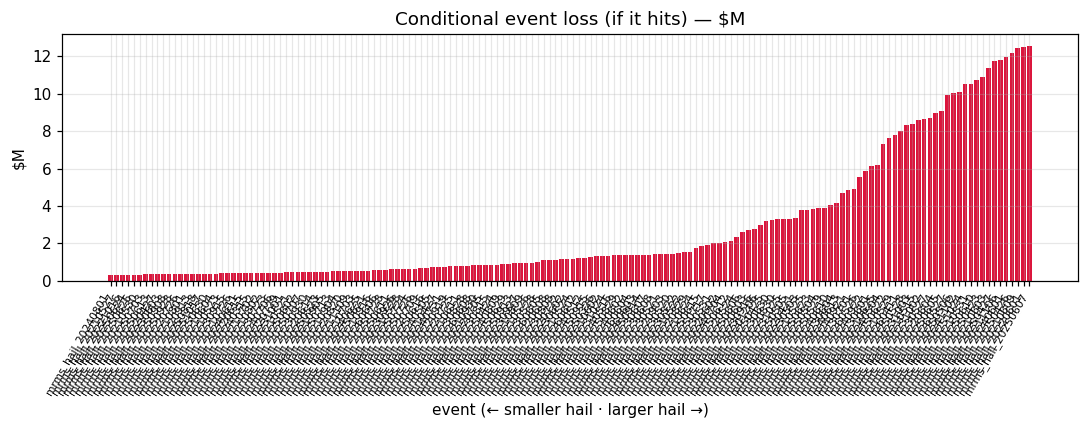

asset value $36.8M · biggest conditional loss $12.6M (34% of value, the 4.67″ event).


In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
d = ev.sort_values("peak_intensity_mm")
ax.bar(d.event_id, d.conditional_loss_usd / 1e6, color="crimson")
ax.set(title="Conditional event loss (if it hits) — $M", ylabel="$M", xlabel="event (← smaller hail · larger hail →)")
ax.set_xticklabels(d.event_id, rotation=60, ha="right", fontsize=7); plt.tight_layout(); plt.show()
print(f"asset value ${ASSET['asset_value_usd']/1e6:.1f}M · biggest conditional loss "
      f"${ev.conditional_loss_usd.max()/1e6:.1f}M ({100*ev.conditional_loss_usd.max()/ASSET['asset_value_usd']:.0f}% of value, "
      f"the {ev.loc[ev.conditional_loss_usd.idxmax(),'peak_intensity_in']:.2f}″ event).")

## 4 · Damage representation — what this stage emits  (A22)

V1 emits a **scalar mean damage ratio** per event (the methodology worked-example choice). Deferred, richer
options — flagged, not built:
- **Conditional damage *distribution*** (not just the mean): two same-size events can damage differently;
  the *spread* feeds the loss tail. Phase 5 will need a severity spread to *sample*, not just the mean — the
  key M3 upgrade for honest VaR/PML.
- **Damage-state vector** (none / slight / moderate / extensive / complete) — finer than a scalar.
- **Duration / business interruption** — *deferred.* The damage ratio is physical repair cost only; the
  downtime it causes → revenue loss is a separate additive stage (methodology §7 + §9), not modeled in v1.

## 5 · Persist the M3 artifact → `data/hail/`

Each event with its `damage_ratio` + `conditional_loss_usd` (the full loss on a hit) + carried `pᵢ` — the
exact pair Phase 5's compound-Poisson Monte Carlo consumes.

In [6]:
m3_cols = ["event_id", "catalog_id", "peak_intensity_mm", "peak_intensity_in", "p_hit",
           "damage_ratio", "conditional_loss_usd", "valid_time_utc", "geometry"]
m3 = ev[m3_cols].copy()
out = ROOT / "data" / "hail"
m3.to_parquet(out / "hayhurst_hail_m3_damage.parquet")
summary = {
    "layer": "M3_damage", "peril": "HAIL", "asset": ASSET["name"], "asset_value_usd": ASSET["asset_value_usd"],
    "severity_source": "capex-weighted subsystem blend (infrasure-damage-curves; NOT fitted from loss history)",
    "curve_id": SPEC["curve_id"],
    "curve_provenance": "infrasure-damage-curves: PV_MODULE+TRACKER logistic (IBHS/IEC/empirical) × NREL capex weights; Asset_DR=Σwᵢ·DRᵢ",
    "asset_max_dr_cap": round(float(cap), 3), "subsystem_weights": {s["subsystem"]: s["capex_weight"] for s in SUBS},
    "damage_representation": "scalar mean damage ratio (v1); distribution/vector + duration/BI deferred (A22)",
    "conditional_loss_rule": "conditional_loss = damage_ratio × asset_value (FULL loss on hit; p_i NOT multiplied in — Phase 5 Bernoulli)",
    "events": int(len(m3)), "max_conditional_loss_usd": float(ev.conditional_loss_usd.max()),
    "provenance": {"plan": "docs/plans/hail/done/phase-4-damage.md", "from": "hayhurst_hail_m2_coupled.parquet"},
}
(out / "hayhurst_hail_m3_summary.json").write_text(json.dumps(summary, indent=2))
print(f"M3 damage: {len(m3)} events → {out/'hayhurst_hail_m3_damage.parquet'}")
print(f"M3 summary:           → {out/'hayhurst_hail_m3_summary.json'}")
m3.drop(columns="geometry").head()

M3 damage: 158 events → /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hail/hayhurst_hail_m3_damage.parquet
M3 summary:           → /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hail/hayhurst_hail_m3_summary.json


,event_id,catalog_id,peak_intensity_mm,peak_intensity_in,p_hit,damage_ratio,conditional_loss_usd,valid_time_utc
0,mrms_hail_20201206,hail_hayhurst_50mi_v1,49.6,1.95,0.000374,0.081325,2990994.0,2020-12-06 23:30:00+00:00
1,mrms_hail_20210427,hail_hayhurst_50mi_v1,34.4,1.35,0.000143,0.020460,752494.0,2021-04-27 23:30:00+00:00
2,mrms_hail_20210515,hail_hayhurst_50mi_v1,69.5,2.74,0.008605,0.233281,8579715.0,2021-05-15 23:30:00+00:00
3,mrms_hail_20210521,hail_hayhurst_50mi_v1,29.2,1.15,0.000300,0.012110,445376.0,2021-05-21 23:30:00+00:00
4,mrms_hail_20210522,hail_hayhurst_50mi_v1,41.8,1.65,0.002644,0.041647,1531714.0,2021-05-22 23:30:00+00:00


## Findings & carried-forward

- **Severity is a capex-weighted subsystem blend, conditional, and full.** Each event's hail size → an
  asset damage ratio = Σ wᵢ·DRᵢ (PV_MODULE + TRACKER, NREL weights; infrasure-damage-curves) → a conditional
  dollar loss. It **saturates at ~34%** — because ~64% of asset value (inverters/substation/electrical/
  civil/SCADA) is hail-immune. This replaces the §12 literature curve that extrapolated to ~100%.
- **The LOTV discipline holds.** `conditional_loss = damage_ratio × asset_value`; **`pᵢ` is carried, never
  multiplied in.** Frequency (`pᵢ`) and severity (conditional loss) stay separate until the Monte Carlo
  combines them stochastically — the whole point of the rebuild.
- **Honest gaps:** scalar mean only (a conditional *distribution* is the tail-relevant upgrade);
  duration/BI deferred (physical repair cost only); the curve is literature-curated with a >75 mm extrapolation — all flagged.
- **Next — Phase 5 (M3→metrics):** the **compound-Poisson Monte Carlo** — per simulated year, draw the hit
  count, `Bernoulli(pᵢ)` per event, full conditional loss on a hit, sum → AEP / take max → OEP; read **EAL,
  VaR, PML, TVaR** off the annual vectors (capping per simulated year, never on a fitted curve). The final
  piece — and the part the old repo actually broke (A24; methodology §8–§10; risk-metrics reference).